Task Report: Analysis of 2013 Wind Data at LGA Airport

SIT 220 TASK 4P - Working with pandas Dataframes (Heterogenous Data)

STUDENT NAME - DEVANSHI TYAGI

STUDENT ID - S223002716

STUDENT EMAIL ADDRESS - s223002716@deakin.edu.au

# ABSTRACT
This report presents a comprehensive analysis of the 2013 wind data at LaGuardia Airport (LGA) in New York.
The primary objective is to process and analyze meteorological data to derive meaningful insights about wind speed patterns. The tasks include converting data to the International System of Units (SI), calculating daily mean wind speeds, visualizing these mean speeds, and identifying the ten windiest days of the year.


# INTRODUCTION
Meteorological data is crucial for various applications, including aviation safety, 
weather forecasting, and climate research. 
This report focuses on the wind speed data recorded at LGA airport in 2013.

The analysis involves several steps: converting the data into SI units, calculating daily mean wind speeds, visualizing these speeds over the year, and identifying the top ten windiest days.
This structured approach allows us to derive insights and trends from the dataset, which can be beneficial for operational and strategic decision-making.


# DATA LOADING AND INITIAL SETUP


First, we load the dataset and perform initial data transformations to convert all relevant columns to the International System of Units (SI). This step ensures consistency and ease of analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

# Load the dataset
df = pd.read_csv("/Users/devanshityagi/Downloads/weather.csv", skiprows=42)


# Display the first few rows of the dataframe to understand its structure
df.head()


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,0,37.04,21.92,53.97,230.0,10.35702,11.918651,0.0,1013.9,10.0,2013-01-01 01:00:00
1,EWR,2013,1,1,1,37.04,21.92,53.97,230.0,13.80936,15.891535,0.0,1013.0,10.0,2013-01-01 02:00:00
2,EWR,2013,1,1,2,37.94,21.92,52.09,230.0,12.65858,14.567241,0.0,1012.6,10.0,2013-01-01 03:00:00
3,EWR,2013,1,1,3,37.94,23.00,54.51,230.0,13.80936,15.891535,0.0,1012.7,10.0,2013-01-01 04:00:00
4,EWR,2013,1,1,4,37.94,24.08,57.04,240.0,14.96014,17.215830,0.0,1012.8,10.0,2013-01-01 05:00:00


# Data Conversion

In this section, we convert all columns to SI units, as previously described.
This step is crucial for maintaining consistency and comparability within the dataset.

In [2]:
# Convert Fahrenheit to Celsius for temperature columns
df['temp'] = (df['temp'] - 32) * 5/9
df['dewp'] = (df['dewp'] - 32) * 5/9

# Convert inches to millimeters for precipitation column
df['precip'] = df['precip'] * 25.4

# Convert miles to meters for visibility column
df['visib'] = df['visib'] * 1609.34

# Convert mph to meters per second for wind speed columns
df['wind_speed'] = df['wind_speed'] * 0.44704
df['wind_gust'] = df['wind_gust'] * 0.44704

# Display the first few rows of the modified dataframe
df.head()



,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,0,2.8,-5.6,53.97,230.0,4.630002,5.328114,0.0,1013.9,16093.4,2013-01-01 01:00:00
1,EWR,2013,1,1,1,2.8,-5.6,53.97,230.0,6.173336,7.104152,0.0,1013.0,16093.4,2013-01-01 02:00:00
2,EWR,2013,1,1,2,3.3,-5.6,52.09,230.0,5.658892,6.512139,0.0,1012.6,16093.4,2013-01-01 03:00:00
3,EWR,2013,1,1,3,3.3,-5.0,54.51,230.0,6.173336,7.104152,0.0,1012.7,16093.4,2013-01-01 04:00:00
4,EWR,2013,1,1,4,3.3,-4.4,57.04,240.0,6.687781,7.696165,0.0,1012.8,16093.4,2013-01-01 05:00:00


# OUTCOME DISCUSSION 
All temperature and dew point values have been converted to degrees Celsius, precipitation to millimeters, visibility to meters, and wind speed and gusts to meters per second.

# Calculation of Daily Mean Wind Speeds

Next, we calculate the daily mean wind speeds at LGA airport for the year 2013. 
This involves grouping the data by year, month, and day and computing the mean wind speed for each day.

In [3]:
# Step 1: Filter the dataset for LGA airport
lga_data = df[df['origin'] == 'LGA']

# Step 2: Group the filtered data by year, month, and day
lga_grouped = lga_data.groupby(['year', 'month', 'day'])

# Step 3: Calculate the mean wind speed for each day
daily_mean_wind_speeds = lga_grouped['wind_speed'].mean()

# Display the first few rows of the result
daily_mean_wind_speeds.head()


year  month  day
2013  1      1      6.687781
             2      6.430559
             3      4.908660
             4      6.880698
             5      5.144447
Name: wind_speed, dtype: float64

# OUTCOME DISCUSSION
We filtered the data for LGA, grouped it by year, month, and day, and calculated the daily mean wind speeds
Therefore, we obtained a series of daily mean wind speeds for LGA airport in 2013, which serves as the basis for subsequent analysis and visualization.

# Visualization of Daily Mean Wind Speeds

We plot the daily mean wind speeds over the year to visualize the trend and variability of wind speeds at LGA.
This visualization helps identify trends and potential anomalies in the wind speed data.


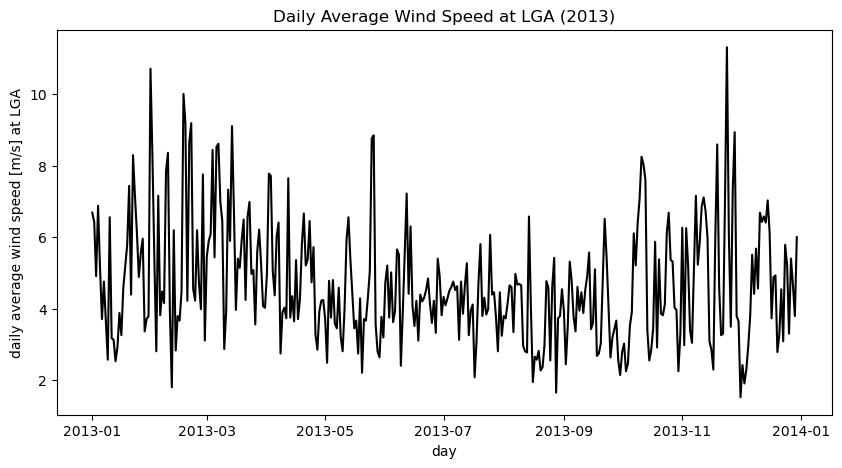

In [4]:
# Filter the dataset for LGA airport
lga_data = df[df['origin'] == 'LGA']

# Group the filtered data by year, month, and day and calculate the mean wind speed for each day
lga_grouped = lga_data.groupby(['year', 'month', 'day'])
daily_mean_wind_speeds = lga_grouped['wind_speed'].mean().reset_index()

# Combine year, month, and day into a single date column
daily_mean_wind_speeds['date'] = pd.to_datetime(daily_mean_wind_speeds[['year', 'month', 'day']])

# Sort by date
daily_mean_wind_speeds = daily_mean_wind_speeds.sort_values(by='date')

# Plot the daily mean wind speeds
plt.figure(figsize=(10, 5))
plt.plot(daily_mean_wind_speeds['date'], daily_mean_wind_speeds['wind_speed'], color='black')
plt.xlabel('day')
plt.ylabel('daily average wind speed [m/s] at LGA')
plt.xticks
plt.title('Daily Average Wind Speed at LGA (2013)')
plt.show()


# OUTCOME DISCUSSION
This plot provides a visual representation of the daily average wind speeds throughout 2013, highlighting periods of higher and lower wind activity.

It reveals significant variability in wind speeds, with notable peaks indicating particularly windy days. 


# Identification of the Ten Windiest Days

Finally, we identify the ten windiest days of the year at LGA, providing both the dates and the corresponding mean daily wind speeds.

In [5]:
# Filter the dataset for LGA airport
lga_data = df[df['origin'] == 'LGA']

# Group the filtered data by year, month, and day and calculate the mean wind speed for each day
lga_grouped = lga_data.groupby(['year', 'month', 'day'])
daily_mean_wind_speeds = lga_grouped['wind_speed'].mean().reset_index()

# Combine year, month, and day into a single date column
daily_mean_wind_speeds['date'] = pd.to_datetime(daily_mean_wind_speeds[['year', 'month', 'day']])

# Sort by date
daily_mean_wind_speeds = daily_mean_wind_speeds.sort_values(by='date')

# Identify the ten windiest days at LGA
top_10_windiest_days = daily_mean_wind_speeds.sort_values(by='wind_speed', ascending=False).head(10)

# Round the wind speeds to two decimal places
top_10_windiest_days['wind_speed'] = top_10_windiest_days['wind_speed'].round(2)

# Reset index for better readability
top_10_windiest_days = top_10_windiest_days.reset_index(drop=True)

# Display the result
print(top_10_windiest_days[['date', 'wind_speed']])


        date  wind_speed
0 2013-11-24       11.32
1 2013-01-31       10.72
2 2013-02-17       10.01
3 2013-02-21        9.19
4 2013-02-18        9.17
5 2013-03-14        9.11
6 2013-11-28        8.94
7 2013-05-26        8.85
8 2013-05-25        8.77
9 2013-02-20        8.66


# OUTCOME DISCUSSION 
We sorted the daily mean wind speeds in descending order and selected the top ten days. 
The wind speeds were rounded to two decimal places for clarity.

The ten windiest days at LGA in 2013, along with their respective wind speeds, are identified and presented. 
This information is useful for understanding extreme wind events at the airport.

# CONCLUSION
This report presents a detailed analysis of wind speed data at LGA airport for the year 2013. By converting the data to SI units, calculating daily mean wind speeds, visualizing these speeds, and identifying the windiest days, we have derived meaningful insights into the wind patterns at LGA.

# Discussion and Future Work
The findings from this analysis provide valuable information for various stakeholders, including airport operations, weather forecasters, and researchers. However, there are several avenues for future work that can enhance the robustness and applicability of this analysis:

* Extending the Time Frame:
Analyzing wind data over multiple years can help identify long-term trends and seasonal patterns. This can provide a more comprehensive understanding of wind behavior at LGA.

* Incorporating Additional Variables:
Including other meteorological variables such as humidity, pressure, and temperature could help understand the factors influencing wind speed and its variability.

* Comparative Analysis:
Comparing the wind patterns at LGA with other airports like JFK and EWR can provide insights into regional weather patterns and their implications for aviation.

* Predictive Modeling:
Developing predictive models using machine learning techniques could help forecast wind speeds based on historical data. This can be particularly useful for planning and operational decision-making.

* Impact Analysis:
Analyzing the impact of extreme wind events on flight operations, delays, and safety can provide actionable insights for airport management and policy makers.

Overall, this report lays the foundation for a deeper exploration of meteorological data, highlighting the importance of comprehensive data analysis in deriving actionable insights and informing strategic decisions.